# Imports and opening the files

In [2]:
#libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import os
import openpyxl
import csv
import sys
import re
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm.notebook import tqdm


In [3]:
csv.field_size_limit(10**7)

# Load in chunks, process each chunk, discard raw text after
results = []
for chunk in pd.read_csv(r"..\data\Newspapers_1.csv", encoding="utf-8", 
                          engine="python", chunksize=500):
    # do your processing here on each chunk, e.g. extract keywords
    results.append(chunk)

news1_df = pd.concat(results, ignore_index=True)

In [4]:
# Load in chunks, process each chunk, discard raw text after
results = []
for chunk in pd.read_csv(r"..\data\Newspapers_2.csv", encoding="utf-8", 
                          engine="python", chunksize=500):
    # do your processing here on each chunk, e.g. extract keywords
    results.append(chunk)

news2_df = pd.concat(results, ignore_index=True)

In [5]:
bonds_df = pd.read_excel(r"..\data\Greece_Germany_Bond_Spread_2010_2026.xlsx")

In [6]:
news1_df.head()

,original_url,final_url,word_count,status,error,date,date_raw,heading_type,article_title,content,extraction_method
0,https://www.capital.gr/diethni/3976815/souidia...,https://www.capital.gr/diethni/3976815/souidia...,148.0,success,NaN,2026-02-26 22:20,"Πέμπτη, 26-Φεβ-2026 22:20",ΔΙΕΘΝΗ,"Drone, πιθανότατα ρωσικό, εντοπίστηκε κοντά στ...",Ένα μη επανδρωμένο αεροσκάφος που εντοπίστηκε ...,readability
1,https://www.capital.gr/diethni/3976810/kouba-o...,https://www.capital.gr/diethni/3976810/kouba-o...,304.0,success,NaN,2026-02-26 21:58,"Πέμπτη, 26-Φεβ-2026 21:58",ΔΙΕΘΝΗ,Ο ένας από τους τέσσερις άνδρες που σκοτώθηκαν...,Ένας από τους τέσσερις άνδρες που σκοτώθηκαν σ...,readability
2,https://www.capital.gr/diethni/3976808/amerika...,https://www.capital.gr/diethni/3976808/amerika...,259.0,success,NaN,2026-02-26 21:39,"Πέμπτη, 26-Φεβ-2026 21:39",ΔΙΕΘΝΗ,Αμερικανοί αξιωματούχοι συναντήθηκαν με τον εγ...,"Αμερικανοί αξιωματούχοι, συνεργάτες του υπουργ...",readability
3,https://www.capital.gr/diethni/3976806/instagr...,https://www.capital.gr/diethni/3976806/instagr...,310.0,success,NaN,2026-02-26 21:28,"Πέμπτη, 26-Φεβ-2026 21:28",ΔΙΕΘΝΗ,Θα ενημερώνει τους γονείς αν το παιδί τους εμφ...,Το Instagram θα προειδοποιεί τους γονείς που έ...,readability
4,https://www.capital.gr/politiki/3976802/k-tsou...,https://www.capital.gr/politiki/3976802/k-tsou...,173.0,success,NaN,2026-02-26 20:58,"Πέμπτη, 26-Φεβ-2026 20:58",ΠΟΛΙΤΙΚΗ,"""Ο κ. Μαρινάκης, πριν ρωτήσει ξανά αν η αντιπο...","Ο εκπρόσωπος Τύπου του ΠΑΣΟΚ-ΚΙΝΑΛ, Κώστας Τσο...",readability


In [7]:
news2_df.head()

,original_url,final_url,word_count,status,error,date,date_raw,heading_type,article_title,content,extraction_method
0,https://www.capital.gr/diethni/3976812/stis-ar...,https://www.capital.gr/diethni/3976812/stis-ar...,143.0,success,NaN,2026-02-26 22:06,"Πέμπτη, 26-Φεβ-2026 22:06",ΔΙΕΘΝΗ,Στις αρχές Μαρτίου στα Εμιράτα η νέα τριμερής ...,Ο επόμενος γύρος των τριμερών ειρηνευτικών δια...,readability
1,https://www.capital.gr/agores/3976809/mikres-m...,https://www.capital.gr/agores/3976809/mikres-m...,282.0,success,NaN,2026-02-26 21:42,"Πέμπτη, 26-Φεβ-2026 21:42",ΑΓΟΡΕΣ,Μικρές μεταβολές ο χρυσός με το βλέμμα στις συ...,Οι τιμές του χρυσού παρέμειναν σχεδόν αμετάβλη...,readability
2,https://www.capital.gr/diethni/3976807/sunanti...,https://www.capital.gr/diethni/3976807/sunanti...,800.0,success,NaN,2026-02-26 21:33,"Πέμπτη, 26-Φεβ-2026 21:33",ΔΙΕΘΝΗ,"Μελόνι: ""Ιταλία και Κύπρος ανήκουν σε έναν...",Ο Κύπριος πρόεδρος Νίκος Χριστοδουλίδης είχε σ...,readability
3,https://www.capital.gr/diethni/3976805/sugkrou...,https://www.capital.gr/diethni/3976805/sugkrou...,224.0,success,NaN,2026-02-26 21:20,"Πέμπτη, 26-Φεβ-2026 21:20",ΔΙΕΘΝΗ,Συγκρούσεις στα σύνορα Πακιστάν - Αφγανιστάν,Οι αρχές των Ταλιμπάν δήλωσαν σήμερα ότι ο αφγ...,readability
4,https://www.capital.gr/diethni/3976801/ipa-ira...,https://www.capital.gr/diethni/3976801/ipa-ira...,220.0,success,NaN,2026-02-26 20:52,"Πέμπτη, 26-Φεβ-2026 20:52",ΔΙΕΘΝΗ,"Ολοκληρώθηκαν οι διαπραγματεύσεις με ""σημαντικ...",Οι διαπραγματεύσεις μεταξύ του Ιράν και των ΗΠ...,readability


In [8]:
bonds_df.head()

,Date,Spread
0,03/01/2026,0.7377
1,02/22/2026,0.6483
2,02/15/2026,0.6095
3,02/08/2026,0.6077
4,02/01/2026,0.6104


# Preprocessing

In [9]:
# Combine both newspaper datasets
df = pd.concat([news1_df, news2_df], ignore_index=True)
# Compute char length
df["char_count"] = df['content'].str.len()

df = df.reset_index(drop=True)
print(f"Total articles: {len(df)}")
df.head()

Total articles: 1566371


,original_url,final_url,word_count,status,error,date,date_raw,heading_type,article_title,content,extraction_method,char_count
0,https://www.capital.gr/diethni/3976815/souidia...,https://www.capital.gr/diethni/3976815/souidia...,148.0,success,NaN,2026-02-26 22:20,"Πέμπτη, 26-Φεβ-2026 22:20",ΔΙΕΘΝΗ,"Drone, πιθανότατα ρωσικό, εντοπίστηκε κοντά στ...",Ένα μη επανδρωμένο αεροσκάφος που εντοπίστηκε ...,readability,1003
1,https://www.capital.gr/diethni/3976810/kouba-o...,https://www.capital.gr/diethni/3976810/kouba-o...,304.0,success,NaN,2026-02-26 21:58,"Πέμπτη, 26-Φεβ-2026 21:58",ΔΙΕΘΝΗ,Ο ένας από τους τέσσερις άνδρες που σκοτώθηκαν...,Ένας από τους τέσσερις άνδρες που σκοτώθηκαν σ...,readability,1978
2,https://www.capital.gr/diethni/3976808/amerika...,https://www.capital.gr/diethni/3976808/amerika...,259.0,success,NaN,2026-02-26 21:39,"Πέμπτη, 26-Φεβ-2026 21:39",ΔΙΕΘΝΗ,Αμερικανοί αξιωματούχοι συναντήθηκαν με τον εγ...,"Αμερικανοί αξιωματούχοι, συνεργάτες του υπουργ...",readability,1800
3,https://www.capital.gr/diethni/3976806/instagr...,https://www.capital.gr/diethni/3976806/instagr...,310.0,success,NaN,2026-02-26 21:28,"Πέμπτη, 26-Φεβ-2026 21:28",ΔΙΕΘΝΗ,Θα ενημερώνει τους γονείς αν το παιδί τους εμφ...,Το Instagram θα προειδοποιεί τους γονείς που έ...,readability,2015
4,https://www.capital.gr/politiki/3976802/k-tsou...,https://www.capital.gr/politiki/3976802/k-tsou...,173.0,success,NaN,2026-02-26 20:58,"Πέμπτη, 26-Φεβ-2026 20:58",ΠΟΛΙΤΙΚΗ,"""Ο κ. Μαρινάκης, πριν ρωτήσει ξανά αν η αντιπο...","Ο εκπρόσωπος Τύπου του ΠΑΣΟΚ-ΚΙΝΑΛ, Κώστας Τσο...",readability,1266


In [10]:
# Check for missing values across all columns
print("=" * 35)
print(f"{'Column':<20} {'NaN Count':>10}")
print("=" * 35)
for col in df.columns:
    print(f"{col:<20} {df[col].isna().sum():>10}")
print("=" * 35)


Column                NaN Count
original_url                  0
final_url                     0
word_count               382862
status                        0
error                   1566371
date                          0
date_raw                 382862
heading_type             369298
article_title                 2
content                       0
extraction_method             0
char_count                    0


In [11]:
# Distribution of status values
print("=" * 35)
print(f"{'Status':<20} {'Count':>10}")
print("=" * 35)
for status, count in df["status"].value_counts().items():
    print(f"{status:<20} {count:>10}")
print("=" * 35)


Status                    Count
success                 1566371


In [12]:
# Distribution of heading types
counts = df["heading_type"].value_counts()
print(f"Total unique heading types: {len(counts)}")
print("=" * 40)
print(f"{'Heading Type':<25} {'Count':>10}")
print("=" * 40)
for heading, count in counts.head(80).items():
    print(f"{heading:<25} {count:>10}")
print("=" * 40)


Total unique heading types: 164
Heading Type                   Count
ΔΙΕΘΝΗ                        230510
ΕΠΙΚΑΙΡΟΤΗΤΑ                  221847
VIDEO_NEWS                    177551
ΟΙΚΟΝΟΜΙΑ                     141472
ΕΠΙΧΕΙΡΗΣΕΙΣ                  113014
ΧΡΗΜ. ΑΝΑΚΟΙΝΩΣΕΙΣ             96891
ΠΟΛΙΤΙΚΗ                       68609
ΑΓΟΡΕΣ                         53309
CAPITALHEALTH                   7201
BRAND VOICE                     5804
ΜΕ ΑΠΟΨΗ                        5782
ΑΡΘΡΑ                           5106
ΠΙΣΩ ΑΠΟ ΤΙΣ ΓΡΑΜΜΕΣ            4906
ΚΩΣΤΑΣ ΣΤΟΥΠΑΣ                  4749
FOREX                           4566
CAPITALTV                       4010
Ο ΓΙΩΡΓΟΣ ΚΡΑΛΟΓΛΟΥ ΓΡΑΦΕΙ       3077
BLOOMBERG OPINION               2967
ΠΑΡΟΥΣΙΑΣΕΙΣ                    2864
ΤΕΧΝΟΛΟΓΙΑ                      2541
ΕΡΕΥΝΕΣ                         2123
REAL ESTATE - ΕΙΔΗΣΕΙΣ          1882
ΕΤΑΙΡΙΚΗ ΚΟΙΝΩΝΙΚΗ ΕΥΘΥΝΗ       1710
CAPITALTECH: INTERNET           1702
Ο ΠΕΤΡΟΣ ΛΑΖΟΣ ΓΡΑΦΕΙ           1650
THINK

In [13]:
df = df.drop(columns=['original_url', 'final_url', 'status', 'error', 'date_raw', 'extraction_method'])

In [14]:
df.head()

,word_count,date,heading_type,article_title,content,char_count
0,148.0,2026-02-26 22:20,ΔΙΕΘΝΗ,"Drone, πιθανότατα ρωσικό, εντοπίστηκε κοντά στ...",Ένα μη επανδρωμένο αεροσκάφος που εντοπίστηκε ...,1003
1,304.0,2026-02-26 21:58,ΔΙΕΘΝΗ,Ο ένας από τους τέσσερις άνδρες που σκοτώθηκαν...,Ένας από τους τέσσερις άνδρες που σκοτώθηκαν σ...,1978
2,259.0,2026-02-26 21:39,ΔΙΕΘΝΗ,Αμερικανοί αξιωματούχοι συναντήθηκαν με τον εγ...,"Αμερικανοί αξιωματούχοι, συνεργάτες του υπουργ...",1800
3,310.0,2026-02-26 21:28,ΔΙΕΘΝΗ,Θα ενημερώνει τους γονείς αν το παιδί τους εμφ...,Το Instagram θα προειδοποιεί τους γονείς που έ...,2015
4,173.0,2026-02-26 20:58,ΠΟΛΙΤΙΚΗ,"""Ο κ. Μαρινάκης, πριν ρωτήσει ξανά αν η αντιπο...","Ο εκπρόσωπος Τύπου του ΠΑΣΟΚ-ΚΙΝΑΛ, Κώστας Τσο...",1266


In [15]:
patterns = df['date'].astype(str).apply(lambda x: re.sub(r'\d', '#', x))
print(patterns.value_counts().to_string())

date
####-##-## ##:##       1183934
####-##-## ##:##:##     334997
####-##-##               47391
##:####/##                  49


In [16]:
for pattern, group in df.groupby(df['date'].astype(str).apply(lambda x: re.sub(r'\d', '#', x))):
    print(f"{pattern}  →  {group['date'].iloc[0]}")

####-##-##  →  2002-05-16
####-##-## ##:##  →  2026-02-26 22:20
####-##-## ##:##:##  →  2004-07-02 15:39:00
##:####/##  →  23:5926/02


In [17]:
# Drop malformed
mask_bad = df['date'].astype(str).str.match(r'^\d{2}:\d{4}/\d{2}')
df = df[~mask_bad].reset_index(drop=True)

# Keep only first 10 chars (YYYY-MM-DD)
df['date'] = df['date'].astype(str).str[:10]

There cannot be a date where tehre is 1 and not 01 because the whole date would be less character and with a check we would catch them, since its zero, tehre isnt a value. 

In [18]:
# Validate date components for hallucinating values
date_parts = df['date'].astype(str).str.extract(r'(\d{2})/(\d{2})/(\d{4})')
date_parts.columns = ['month', 'day', 'year']
date_parts = date_parts.astype(float)

print("Date Component Validation")
print("=" * 40)
print(f"{'Year':<10} min: {date_parts['year'].min():.0f}   max: {date_parts['year'].max():.0f}")
print(f"{'Month':<10} min: {date_parts['month'].min():.0f}   max: {date_parts['month'].max():.0f}   (valid: 1-12)")
print(f"{'Day':<10} min: {date_parts['day'].min():.0f}   max: {date_parts['day'].max():.0f}   (valid: 1-31)")
print("=" * 40)
print(f"{'Month > 12:':<20} {(date_parts['month'] > 12).sum():>10}")
print(f"{'Day > 31:':<20} {(date_parts['day'] > 31).sum():>10}")
print(f"{'Month == 0:':<20} {(date_parts['month'] == 0).sum():>10}")
print(f"{'Day == 0:':<20} {(date_parts['day'] == 0).sum():>10}")
print("=" * 40)


Date Component Validation
Year       min: nan   max: nan
Month      min: nan   max: nan   (valid: 1-12)
Day        min: nan   max: nan   (valid: 1-31)
Month > 12:                   0
Day > 31:                     0
Month == 0:                   0
Day == 0:                     0


In [19]:
# Check for malformed short dates
short = df[df['date'].str.len() < 10]['date']
print("=" * 35)
print(f"{'Dates shorter than 10 chars:':<28} {len(short):>5}")
print("=" * 35)
if len(short) > 0:
    print(f"{'Value':<20} {'Count':>10}")
    print("-" * 35)
    print(short.value_counts().to_string())
print("=" * 35)


Dates shorter than 10 chars:     0


In [20]:
# Convert and validate date format (MM/DD/YYYY)
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d', errors='coerce').dt.strftime('%m/%d/%Y')

print("Date Validation")
print("=" * 30)
print(f"{'NaN / NaT:':<15} {df['date'].isna().sum():>10}")
print(f"{'nan string:':<15} {(df['date'] == 'nan').sum():>10}")
print(f"{'empty string:':<15} {(df['date'] == '').sum():>10}")
print(f"{'len != 10:':<15} {(df['date'].str.len() != 10).sum():>10}")
print("=" * 30)
print(f"\nSample:\n{df['date'].head(5).to_string()}")


Date Validation
NaN / NaT:               0
nan string:              0
empty string:            0
len != 10:               0

Sample:
0    02/26/2026
1    02/26/2026
2    02/26/2026
3    02/26/2026
4    02/26/2026


In [21]:
df.head()

,word_count,date,heading_type,article_title,content,char_count
0,148.0,02/26/2026,ΔΙΕΘΝΗ,"Drone, πιθανότατα ρωσικό, εντοπίστηκε κοντά στ...",Ένα μη επανδρωμένο αεροσκάφος που εντοπίστηκε ...,1003
1,304.0,02/26/2026,ΔΙΕΘΝΗ,Ο ένας από τους τέσσερις άνδρες που σκοτώθηκαν...,Ένας από τους τέσσερις άνδρες που σκοτώθηκαν σ...,1978
2,259.0,02/26/2026,ΔΙΕΘΝΗ,Αμερικανοί αξιωματούχοι συναντήθηκαν με τον εγ...,"Αμερικανοί αξιωματούχοι, συνεργάτες του υπουργ...",1800
3,310.0,02/26/2026,ΔΙΕΘΝΗ,Θα ενημερώνει τους γονείς αν το παιδί τους εμφ...,Το Instagram θα προειδοποιεί τους γονείς που έ...,2015
4,173.0,02/26/2026,ΠΟΛΙΤΙΚΗ,"""Ο κ. Μαρινάκης, πριν ρωτήσει ξανά αν η αντιπο...","Ο εκπρόσωπος Τύπου του ΠΑΣΟΚ-ΚΙΝΑΛ, Κώστας Τσο...",1266


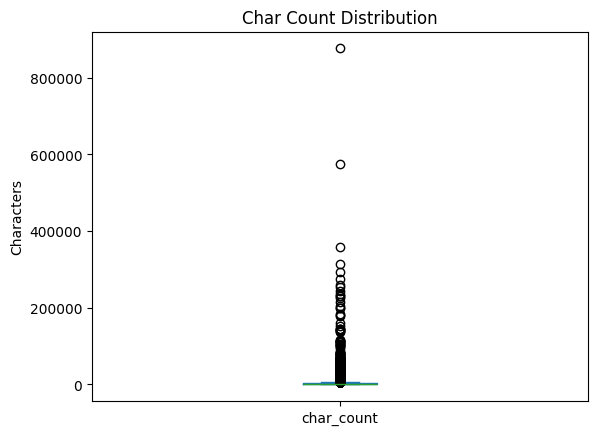

In [22]:
df['char_count'].plot(kind='box', title='Char Count Distribution')
plt.ylabel('Characters')
plt.show()

In [23]:
df["char_count"].describe()

count    1.566322e+06
mean     1.926623e+03
std      2.548777e+03
min      2.500000e+01
25%      5.200000e+02
50%      1.255000e+03
75%      2.573000e+03
max      8.769860e+05
Name: char_count, dtype: float64

In [24]:
# Percentage of articles below each character count threshold
print("=" * 35)
print(f"{'Threshold':<15} {'% of Articles':>15}")
print("=" * 35)
for threshold in [5000, 6000, 7000, 8000, 9000, 10000]:
    pct = (df['char_count'] < threshold).sum() / len(df) * 100
    print(f"< {threshold:>6} chars   {pct:>12.1f}%")
print("=" * 35)


Threshold         % of Articles
<   5000 chars           92.8%
<   6000 chars           95.5%
<   7000 chars           97.0%
<   8000 chars           97.9%
<   9000 chars           98.5%
<  10000 chars           98.9%


In [25]:
# Truncate content to 5000 chars and update char_count
df['content'] = df['content'].str[:5000]
df['char_count'] = df['content'].str.len()

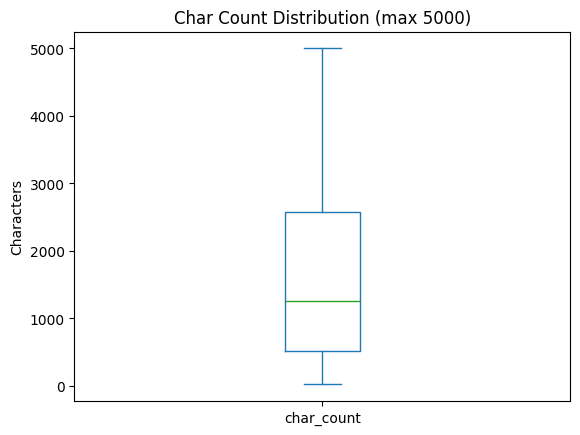

In [26]:
df['char_count'].plot(kind='box', title='Char Count Distribution (max 5000)')
plt.ylabel('Characters')
plt.show()

In [27]:
for cat in df['heading_type'].value_counts().index:
    print(cat)


ΔΙΕΘΝΗ
ΕΠΙΚΑΙΡΟΤΗΤΑ
VIDEO_NEWS
ΟΙΚΟΝΟΜΙΑ
ΕΠΙΧΕΙΡΗΣΕΙΣ
ΧΡΗΜ. ΑΝΑΚΟΙΝΩΣΕΙΣ
ΠΟΛΙΤΙΚΗ
ΑΓΟΡΕΣ
CAPITALHEALTH
BRAND VOICE
ΜΕ ΑΠΟΨΗ
ΑΡΘΡΑ
ΠΙΣΩ ΑΠΟ ΤΙΣ ΓΡΑΜΜΕΣ
ΚΩΣΤΑΣ ΣΤΟΥΠΑΣ
FOREX
CAPITALTV
Ο ΓΙΩΡΓΟΣ ΚΡΑΛΟΓΛΟΥ ΓΡΑΦΕΙ
BLOOMBERG OPINION
ΠΑΡΟΥΣΙΑΣΕΙΣ
ΤΕΧΝΟΛΟΓΙΑ
ΕΡΕΥΝΕΣ
REAL ESTATE - ΕΙΔΗΣΕΙΣ
ΕΤΑΙΡΙΚΗ ΚΟΙΝΩΝΙΚΗ ΕΥΘΥΝΗ
CAPITALTECH: INTERNET
Ο ΠΕΤΡΟΣ ΛΑΖΟΣ ΓΡΑΦΕΙ
THINK TANK
BUSINESSWEEK ONLINE
CAPITALTECH: ΨΥΧΑΓΩΓΙΑ
ENGLISH
Ο ΔΗΜΗΤΡΗΣ ΠΑΠΑΚΩΝΣΤΑΝΤΙΝΟΥ ΓΡΑΦΕΙ
ΑΓΟΡΑ ΑΥΤΟΚΙΝΗΤΟΥ
ΑΝΑΛΥΣΗ
CAPITAL LOGISTIS
ΔΙΑΤΡΟΦΗ
ΣΙΩΠΗΤΗΡΙΟ
Εκλογες Σεπτεμβριος 2015
DELPHI ECONOMIC FORUM
BREXIT
CAPITALTECH: SOFTWARE
IN THE MONEY
ΣΥΝΕΝΤΕΥΞΕΙΣ
ΕΥΕΞΙΑ
ΑΚΙΝΗΤΑ
ΧΡΗΣΤΟΣ ΧΩΜΕΝΙΔΗΣ
ΝΕΕΣ ΘΕΡΑΠΕΙΕΣ
ΦΟΡΟΑΠΟΨΕΙΣ
ΔΗΜΟΤΙΚΕΣ ΕΚΛΟΓΕΣ
ΑΓΩΝΕΣ
EUROBASKET 2017
TRAVEL
ΔΟΚΙΜΕΣ
TAX: ΕΠΙΧΕΙΡ/ΕΛ.ΕΠΑΓΓ.
ΓΑΛΛΙΑ ΕΚΛΟΓΕΣ
PCMAGAZINE: ΑΠΟΨΕΙΣ
ΑΝΤΙΛΟΓΙΕΣ
BLOOMBERG BUSINESSWEEK
RED ALERT
ΟΙΚΟΓΕΝΕΙΑ
FITNESS
Ο ΑΓΗΣ ΒΕΡΟΥΤΗΣ ΓΡΑΦΕΙ
PCMAGAZINE
ΕΚΛΟΓΕΣ ΗΠΑ
TAX: ΦΟΡΟΛΟΓΙΚΕΣ ΔΗΛΩΣΕΙΣ
ΕΚΛΟΓΕΣ ΓΕΡΜΑΝΙΑ
TAX: ΑΝΑΛΥΣΗ - ΕΡΕΥΝΑ
DELPHI ECONOMIC FORUM X
RE: ΑΝΑΛΥΣΕΙΣ


In [28]:
# Drop irrelevant categories (lifestyle, health, sports, entertainment)
trash_categories = [
    'CAPITALHEALTH', 'BRAND VOICE', 'ΔΙΑΤΡΟΦΗ', 'ΕΥΕΞΙΑ', 'ΝΕΕΣ ΘΕΡΑΠΕΙΕΣ', 
    'ΑΓΩΝΕΣ', 'EUROBASKET 2017', 'ΟΙΚΟΓΕΝΕΙΑ', 'FITNESS', 'SEX & ΥΓΕΙΑ', 
    'ASK MAN', 'ΟΛΥΜΠΙΑΚΟΙ ΑΓΩΝΕΣ', 'EKO RALLY ACROPOLIS', 'H ΝΕΑ ΙΑΤΡΙΚΗ 2023', 
    'ΥΓΕΙΑ', 'BRΑND VOICE', 'ΑΠΟΔΡΑΣΕΙΣ', 'AUTO MOTO', 
    'ΟΔΗΓΟΣ ΑΓΟΡΑΣ(ΜΕΤΑΧΕΙΡΙΣΜΕΝΟΥ)', 'ΦΑΚΕΛΟΣ ΥΓΕΙΑΣ', 'ESQUIRE', 'TRAVEL', 'TRAVEL: ΓΕΝΙΚΑ', 'ΑΓΟΡΑ ΑΥΤΟΚΙΝΗΤΟΥ',
]

df = df[~df['heading_type'].isin(trash_categories)].reset_index(drop=True)
print(f"Rows remaining: {len(df)}")


Rows remaining: 1547572


# Embeddings Creation

In [29]:
# Drop articles before 2010 (bond spread data starts from 2010)
before = len(df)
df = df[pd.to_datetime(df['date'], format='%m/%d/%Y').dt.year >= 2010].reset_index(drop=True)
print(f"Dropped {before - len(df):,} articles before 2010. Remaining: {len(df):,}")


Dropped 274,277 articles before 2010. Remaining: 1,273,295


In [30]:
import unicodedata

def strip_accents(s):
    return "".join(
        c for c in unicodedata.normalize("NFD", s)
        if unicodedata.category(c) != "Mn"
    )

epu_terms = {
    "UNCERTAINTY": ["αβεβαιοτητ", "ασαφ", "αμφιβολ", "ανησυχ", "ασταθ", "κινδυν", "απροβλεπτ", "απειλ", "ευαλωτ"],
    "ECONOMY": ["οικονομ", "αναπτυξ", "υφεσ", "ανεργ", "απασχολ", "επενδυσ", "εξαγωγ", "εισαγωγ", "εμπορ", "αεπ", "μισθ", "εισοδημ", "παραγωγ"],
    "POLICY": ["βουλ", "νομοθεσ", "κυβερνησ", "τραπεζ ελλαδ", "κεντρικ τραπεζ", "μεταρρυθμ", "διαρθρωτικ αλλαγ", "νομ", "υπουργ", "πρωθυπουργ", "μαξιμ", "ελλειμμ", "απορυθμ", "κανονιστικ πλαισ", "επιτροπ κεφαλαιαγορ", "επιτροπ ανταγωνισμ", "συμβουλ επικρατ"]
}

# Pre-normalise: lowercase + strip accents — done once, reused for matching
def normalize(text):
    return strip_accents(str(text).lower())

# Flatten all stems per language into a single set per category (for fast lookup)
epu_categories = list(epu_terms.keys())  # same keys for

In [33]:
import time

# Regex to remove combining accent marks (U+0300–U+036F) after NFD decomposition
# Strips accents while keeping Greek base letters
_combining = re.compile(r"[\u0300-\u036f]")

def strip_accents_fast(s):
    return _combining.sub("", unicodedata.normalize("NFD", s))

# Pre-compile keyword patterns
cat_patterns = {
    cat: re.compile("|".join(re.escape(kw) for kw in keywords))
    for cat, keywords in epu_terms.items()
}
cat_list = list(epu_terms.keys())
for cat in cat_list:
    df[f"hit_{cat}"] = False

CHUNK = 100_000
n = len(df)
t0 = time.time()
print(f"Processing {n:,} articles in chunks of {CHUNK:,}...\n")

for start in range(0, n, CHUNK):
    end = min(start + CHUNK, n)
    chunk_norm = (
        df["content"].iloc[start:end]
        .str.lower()
        .apply(strip_accents_fast)
    )
    for cat, pattern in cat_patterns.items():
        df.loc[df.index[start:end], f"hit_{cat}"] = chunk_norm.str.contains(pattern, regex=True).values

    elapsed = time.time() - t0
    eta = (elapsed / end) * (n - end)
    print(f"  {end:>9,} / {n:,}  ({end/n*100:.1f}%)  elapsed: {elapsed:.0f}s  ETA: {eta:.0f}s")

hit_cols = [f"hit_{cat}" for cat in cat_list]
df["cat_hits"] = df[hit_cols].sum(axis=1)

print(f"\nDone in {time.time()-t0:.0f}s")
print("\nCategory hit distribution:")
print(df["cat_hits"].value_counts().sort_index().to_string())
print(f"\nTotal articles:               {n:>10,}")
print(f"Articles matching ≥2 cats:    {(df['cat_hits'] >= 2).sum():>10,}")


Processing 1,273,295 articles in chunks of 100,000...

    100,000 / 1,273,295  (7.9%)  elapsed: 34s  ETA: 399s
    200,000 / 1,273,295  (15.7%)  elapsed: 65s  ETA: 351s
    300,000 / 1,273,295  (23.6%)  elapsed: 96s  ETA: 311s
    400,000 / 1,273,295  (31.4%)  elapsed: 121s  ETA: 265s
    500,000 / 1,273,295  (39.3%)  elapsed: 138s  ETA: 214s
    600,000 / 1,273,295  (47.1%)  elapsed: 152s  ETA: 171s
    700,000 / 1,273,295  (55.0%)  elapsed: 182s  ETA: 149s
    800,000 / 1,273,295  (62.8%)  elapsed: 214s  ETA: 127s
    900,000 / 1,273,295  (70.7%)  elapsed: 255s  ETA: 106s
  1,000,000 / 1,273,295  (78.5%)  elapsed: 285s  ETA: 78s
  1,100,000 / 1,273,295  (86.4%)  elapsed: 309s  ETA: 49s
  1,200,000 / 1,273,295  (94.2%)  elapsed: 321s  ETA: 20s
  1,273,295 / 1,273,295  (100.0%)  elapsed: 336s  ETA: 0s

Done in 337s

Category hit distribution:
cat_hits
0    339455
1    321979
2    449087
3    162774

Total articles:                1,273,295
Articles matching ≥2 cats:       611,861


In [64]:
df_epu = df[df["cat_hits"] >= 1].drop(columns=hit_cols + ["cat_hits"]).reset_index(drop=True)
print(f"Filtered corpus: {len(df_epu):,} articles ({len(df_epu)/len(df)*100:.1f}% of total)")


Filtered corpus: 933,840 articles (73.3% of total)


In [63]:
import os, gzip, shutil, urllib.request
from gensim.models import KeyedVectors

GZ_PATH  = os.path.normpath(os.path.join("..", "cc.el.300.vec.gz"))
VEC_PATH = os.path.normpath(os.path.join("..", "cc.el.300.vec"))
URL = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.el.300.vec.gz"

if not os.path.exists(VEC_PATH):
    if not os.path.exists(GZ_PATH):
        print("Downloading Greek FastText vectors (~1.2 GB)...")
        def progress(count, block_size, total_size):
            pct = count * block_size / total_size * 100
            print(f"\r  {min(pct,100):.1f}%", end="", flush=True)
        urllib.request.urlretrieve(URL, GZ_PATH, reporthook=progress)
        print("\nDownload complete.")
    print("Extracting .gz (~2 GB)...")
    with gzip.open(GZ_PATH, "rb") as f_in, open(VEC_PATH, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)
    print("Extraction complete.")
else:
    print(f"Vectors already exist at: {VEC_PATH}")

# Load only top 500K most frequent words (~560 MB RAM instead of 2.24 GB)
print("Loading vectors (top 500K words)...")
ft = KeyedVectors.load_word2vec_format(VEC_PATH, binary=False, limit=500_000)
print(f"Loaded {len(ft):,} vectors, dimension: {ft.vector_size}")


Vectors already exist at: ..\cc.el.300.vec
Loading vectors (top 500K words)...


MemoryError: Unable to allocate 572. MiB for an array with shape (500000, 300) and data type float32

In [65]:
def doc_vector(text, model):
    """Mean of word vectors for tokens present in vocabulary."""
    tokens = text.strip().split()
    vecs = [model[t] for t in tokens if t in model]
    if not vecs:
        return np.zeros(model.vector_size, dtype=np.float32)
    return np.mean(vecs, axis=0).astype(np.float32)

def cosine_sim(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na == 0 or nb == 0:
        return 0.0
    return float(np.dot(a, b) / (na * nb))

In [66]:
# Build one reference vector per EPU category (mean of its keyword vectors)
ref_vectors = {}
for cat, terms in epu_terms.items():
    vecs = [doc_vector(t, ft) for t in terms]
    ref_vectors[cat] = np.mean(vecs, axis=0).astype(np.float32)
    print(f"{cat:15s}: ref vector built from {len(terms)} keywords")


UNCERTAINTY    : ref vector built from 9 keywords
ECONOMY        : ref vector built from 13 keywords
POLICY         : ref vector built from 17 keywords


In [67]:
# Score each article in df_epu: cosine similarity vs each category reference vector
from tqdm.notebook import tqdm

cats = list(ref_vectors.keys())
n = len(df_epu)
sim_matrix = np.zeros((n, len(cats)), dtype=np.float32)

for i, text in enumerate(tqdm(df_epu["content"], desc="Embedding articles")):
    vec = doc_vector(str(text), ft)
    for j, cat in enumerate(cats):
        sim_matrix[i, j] = cosine_sim(vec, ref_vectors[cat])

for j, cat in enumerate(cats):
    df_epu[f"sim_{cat}"] = sim_matrix[:, j]

# EPU score = max similarity across the 3 categories
df_epu["sim_EPU"] = sim_matrix.max(axis=1)

print("Done.")
df_epu[[f"sim_{cat}" for cat in cats] + ["sim_EPU"]].describe().round(4)


Embedding articles:   0%|          | 0/933840 [00:00<?, ?it/s]

Done.


,sim_UNCERTAINTY,sim_ECONOMY,sim_POLICY,sim_EPU
count,933840.0000,933840.0000,933840.0000,933840.0000
mean,0.1302,0.3342,0.3136,0.3397
std,0.0283,0.0352,0.0339,0.0335
min,-0.1543,0.0398,0.0065,0.0398
25%,0.1166,0.3104,0.2928,0.3175
50%,0.1354,0.3318,0.3140,0.3384
75%,0.1495,0.3574,0.3355,0.3617
max,0.2681,0.4926,0.4883,0.4926


In [69]:
# Aggregate EPU scores to monthly means
sim_cols = [f"sim_{cat}" for cat in epu_terms] + ["sim_EPU"]

df_epu["month"] = pd.to_datetime(df_epu["date"], format="%m/%d/%Y").dt.to_period("M")
monthly = df_epu.groupby("month")[sim_cols].mean().reset_index()
monthly["month_dt"] = monthly["month"].dt.to_timestamp()

print(f"Monthly EPU index: {len(monthly)} months ({monthly['month'].min()} – {monthly['month'].max()})")
monthly[["month", "sim_EPU"]].tail(12)

Monthly EPU index: 194 months (2010-01 – 2026-02)


,month,sim_EPU
182,2025-03,0.335420
183,2025-04,0.338321
184,2025-05,0.337472
185,2025-06,0.337048
186,2025-07,0.336910
187,2025-08,0.335752
188,2025-09,0.336347
189,2025-10,0.336107
190,2025-11,0.336143
191,2025-12,0.336806


In [70]:
# Prepare bond spread: aggregate to monthly mean
bonds_df["month_dt"] = pd.to_datetime(bonds_df["Date"], format="%m/%d/%Y")
bonds_df["month"] = bonds_df["month_dt"].dt.to_period("M")
bonds_monthly = bonds_df.groupby("month")["Spread"].mean().reset_index()

# Merge on month
merged = monthly.merge(bonds_monthly, on="month", how="inner")
print(f"Merged: {len(merged)} months  ({merged['month'].min()} – {merged['month'].max()})")
merged[["month", "sim_EPU", "Spread"]].head(12)

Merged: 194 months  (2010-01 – 2026-02)


,month,sim_EPU,Spread
0,2010-01,0.349478,3.05300
1,2010-02,0.351055,3.15450
2,2010-03,0.351956,3.22375
3,2010-04,0.352191,5.00900
4,2010-05,0.355926,6.17740
5,2010-06,0.356294,7.04650
6,2010-07,0.353260,7.73625
7,2010-08,0.356861,8.62820
8,2010-09,0.348504,8.90950
9,2010-10,0.347003,7.71720


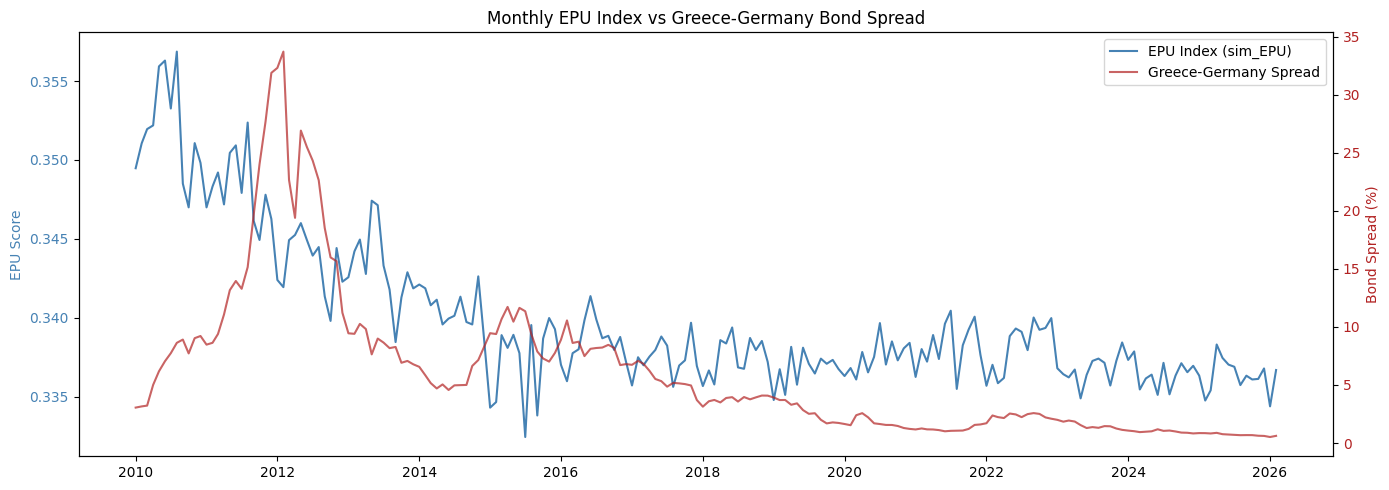

In [71]:
# Plot EPU index vs Bond Spread over time
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(merged["month_dt"], merged["sim_EPU"], color="steelblue", label="EPU Index (sim_EPU)")
ax1.set_ylabel("EPU Score", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(merged["month_dt"], merged["Spread"], color="firebrick", alpha=0.7, label="Greece-Germany Spread")
ax2.set_ylabel("Bond Spread (%)", color="firebrick")
ax2.tick_params(axis="y", labelcolor="firebrick")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("Monthly EPU Index vs Greece-Germany Bond Spread")
plt.tight_layout()
plt.show()


In [72]:
# Pearson & Spearman correlation between EPU index and bond spread
from scipy import stats

pearson_r, pearson_p = stats.pearsonr(merged["sim_EPU"], merged["Spread"])
spearman_r, spearman_p = stats.spearmanr(merged["sim_EPU"], merged["Spread"])

print("Correlation: EPU Index vs Greece-Germany Bond Spread")
print("=" * 50)
print(f"{'Pearson r:':<20} {pearson_r:>8.4f}   (p={pearson_p:.4f})")
print(f"{'Spearman r:':<20} {spearman_r:>8.4f}   (p={spearman_p:.4f})")


Correlation: EPU Index vs Greece-Germany Bond Spread
Pearson r:             0.4836   (p=0.0000)
Spearman r:            0.5990   (p=0.0000)


In [73]:
# OLS multivariate regression: Spread ~ sim_UNCERTAINTY + sim_ECONOMY + sim_POLICY
import statsmodels.api as sm

X = merged[[f"sim_{cat}" for cat in epu_terms]]
y = merged["Spread"]

X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Spread   R-squared:                       0.444
Model:                            OLS   Adj. R-squared:                  0.435
Method:                 Least Squares   F-statistic:                     50.54
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           4.63e-24
Time:                        18:50:31   Log-Likelihood:                -577.86
No. Observations:                 194   AIC:                             1164.
Df Residuals:                     190   BIC:                             1177.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             361.2338     72.428     